In [ ]:
!pip install --upgrade lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 74.8 MB/s eta 0:00:00
  Attempting uninstall: lightgbm
    Found existing installation: lightgbm 4.5.0
    Uninstalling lightgbm-4.5.0:
      Successfully uninstalled lightgbm-4.5.0


Import des bibliothèques

In [ ]:
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import numpy as np
from lightgbm import early_stopping

Chargement des jeux de données

In [ ]:
train = pd.read_csv('/content/donnees_train.csv')
val = pd.read_csv('/content/donnees_val.csv')
test = pd.read_csv('/content/donnees_test.csv')

Définition des colonnes cibles et des features

In [ ]:
target_column = "PuissanceActive (kW)"
feature_columns = [
    'VitesseVent (m/s)', 'DirectionVent (°)', 'Temperature (°C)',
    'Saison', 'Annee', 'Mois', 'Jour', 'Heure','Minute',
    'JourNuit', 'deviation', 'deviation_percentage', 'usability'
]

Séparation des données en features et cibles

In [ ]:
X_train = train[feature_columns]
y_train = train[target_column]

X_val = val[feature_columns]
y_val = val[target_column]

Filtrage des données (VitesseVent entre 3 et 25)

In [ ]:
mask_train = (X_train['VitesseVent (m/s)'] > 3) & (X_train['VitesseVent (m/s)'] <= 25)
X_train_filtered = X_train[mask_train]
y_train_filtered = y_train[mask_train]

mask_val = (X_val['VitesseVent (m/s)'] > 3) & (X_val['VitesseVent (m/s)'] <= 25)
X_val_filtered = X_val[mask_val]
y_val_filtered = y_val[mask_val]

Normalisation des données (MinMaxScaler)

In [ ]:
scaler_X = MinMaxScaler()
X_train_scaled = pd.DataFrame(scaler_X.fit_transform(X_train_filtered), columns=X_train_filtered.columns)
X_val_scaled = pd.DataFrame(scaler_X.transform(X_val_filtered), columns=X_val_filtered.columns)

scaler_y = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(y_train_filtered.values.reshape(-1, 1)).flatten()
y_val_scaled = scaler_y.transform(y_val_filtered.values.reshape(-1, 1)).flatten()

Génération des poids pour l’entraînement

In [ ]:
def generate_weights(y_values):
    return np.select(
        [
            y_values < 1000,
            y_values < 8000,
            y_values >= 8000
        ],
        [2.0, 2.0, 14.0]
    )

weights_train = generate_weights(y_train_filtered)

Préparation des datasets LightGBM

In [ ]:
lgb_train = lgb.Dataset(X_train_scaled, label=y_train_scaled, weight=weights_train)
lgb_val = lgb.Dataset(X_val_scaled, label=y_val_scaled, reference=lgb_train)

Entraînement

In [ ]:
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.08,
    'max_depth': 10,
    'verbose': -1,
    'seed': 42
}

callbacks = [early_stopping(stopping_rounds=50, verbose=True)]

model_tuned = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_train, lgb_val],
    valid_names=['train', 'validation'],
    callbacks=callbacks
)

print(f"Meilleur nombre d'arbres (best_iteration) : {model_tuned.best_iteration}")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[480]	train's rmse: 0.0102607	validation's rmse: 0.0106051
Meilleur nombre d'arbres (best_iteration) : 480


Réentraînement sur train+val (modèle final)

In [ ]:
full_train = pd.concat([train, val], ignore_index=True)
X_full = full_train[feature_columns]
y_full = full_train[target_column]

mask_full = (X_full['VitesseVent (m/s)'] > 3) & (X_full['VitesseVent (m/s)'] <= 25)
X_full_filtered = X_full[mask_full]
y_full_filtered = y_full[mask_full]

scaler_X_final = MinMaxScaler()
X_full_scaled = pd.DataFrame(scaler_X_final.fit_transform(X_full_filtered), columns=X_full_filtered.columns)

scaler_y_final = MinMaxScaler()
y_full_scaled = scaler_y_final.fit_transform(y_full_filtered.values.reshape(-1, 1)).flatten()

weights_full = generate_weights(y_full_filtered)
lgb_full = lgb.Dataset(X_full_scaled, label=y_full_scaled, weight=weights_full)

model_final = lgb.train(
    params,
    lgb_full,
    num_boost_round=model_tuned.best_iteration,
)

Préparation du jeu de test

In [ ]:
test.dropna(inplace=True)
test.reset_index(drop=True, inplace=True)

X_test = test[feature_columns]
y_test = test[target_column].reset_index(drop=True)

mask_test = (X_test['VitesseVent (m/s)'] > 3) & (X_test['VitesseVent (m/s)'] <= 25)
X_test_masked = X_test[mask_test]
y_test_masked = y_test[mask_test]

X_test_scaled = pd.DataFrame(scaler_X_final.transform(X_test_masked), columns=X_test_masked.columns)

Prédictions et dénormalisation

In [ ]:
y_pred_scaled = model_final.predict(X_test_scaled)
y_pred = scaler_y_final.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

y_pred_final = np.zeros(len(X_test))
y_pred_final[mask_test] = y_pred
y_pred_final[~mask_test] = 0

Évaluation du modèle sur le test

avec mask

In [2]:
y_test_used = y_test[mask_test]/ 1000
y_pred_used = y_pred_final[mask_test]/ 1000

mse = mean_squared_error(y_test_used, y_pred_used)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_used, y_pred_used)
r2 = r2_score(y_test_used, y_pred_used)
mape = np.mean(np.abs((y_test_used - y_pred_used) / y_test_used.clip(lower=1e-8))) * 100
smape = 100 * np.mean(
    2 * np.abs(y_pred_used - y_test_used) / (np.abs(y_test_used) + np.abs(y_pred_used) + 1e-8)
)
range_y = np.max(y_test_used) - np.min(y_test_used)
nrmse_range = (rmse / range_y) * 100
nmse_range = (mse / (range_y ** 2)) * 100
nmae = (mae / range_y) * 100 if range_y > 0 else float("inf")

print("Évaluation sur test filtré uniquement (VitesseVent > 3 et <= 25 m/s) :")
print(f" - MSE   : {mse:.4f}MW²")
print(f" - RMSE  : {rmse:.4f}MW")
print(f" - MAE   : {mae:.4f}MW")
print(f" - R2    : {r2:.4f}")
print(f" - MAPE  : {mape:.4f}%")
print(f" - SMAPE  : {smape:.4f}%")
print(f" - NRMSE : {nrmse_range:.4f}%")
print(f" - NMSE  : {nmse_range:.4f}%")
print(f" - NMAE   : {nmae:.4f}%")

Évaluation sur test filtré uniquement (VitesseVent > 3 et <= 25 m/s) :
 - MSE   : 0.0092MW²
 - RMSE  : 0.0959MW
 - MAE   : 0.0601MW
 - R2    : 0.9975
 - MAPE  : 7.1184%
 - SMAPE  : 6.6548%
 - NRMSE : 0.9454%
 - NMSE  : 0.0089%
 - NMAE   : 0.5922%


Sur lenssemble de test

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Conversion en mégawatts (MW)
y_test_mw = y_test / 1000
y_pred_mw = y_pred_final / 1000

# Calcul des métriques
mse = mean_squared_error(y_test_mw, y_pred_mw)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_mw, y_pred_mw)
r2 = r2_score(y_test_mw, y_pred_mw)
mape = np.mean(np.abs((y_test_mw - y_pred_mw) / y_test_mw.clip(lower=1e-8))) * 100
smape = 100 * np.mean(
    2 * np.abs(y_pred_mw - y_test_mw) / (np.abs(y_test_mw) + np.abs(y_pred_mw) + 1e-8)
)
range_y = np.max(y_test_mw) - np.min(y_test_mw)
nrmse_range = (rmse / range_y) * 100 if range_y > 0 else float("inf")
nmse_range = (mse / (range_y ** 2)) * 100 if range_y > 0 else float("inf")
nmae = (mae / range_y) * 100 if range_y > 0 else float("inf")

print("Évaluation sur le jeu de test (en MW) :")
print(f" - MSE    : {mse:.4f} MW²")
print(f" - RMSE   : {rmse:.4f} MW")
print(f" - MAE    : {mae:.4f} MW")
print(f" - R2     : {r2:.4f}")
print(f" - MAPE   : {mape:.4f}%")
print(f" - SMAPE  : {smape:.4f}%")
print(f" - NMSE   : {nmse_range:.4f}%")
print(f" - NRMSE  : {nrmse_range:.4f}%")
print(f" - NMAE   : {nmae:.4f}%")

Évaluation sur le jeu de test (en MW) :
 - MSE    : 0.0077 MW²
 - RMSE   : 0.0875 MW
 - MAE    : 0.0500 MW
 - R2     : 0.9978
 - MAPE   : 5.9411%
 - SMAPE  : 5.5698%
 - NMSE   : 0.0074%
 - NRMSE  : 0.8580%
 - NMAE   : 0.4905%


Visualisation des prédictions vs vraies valeurs

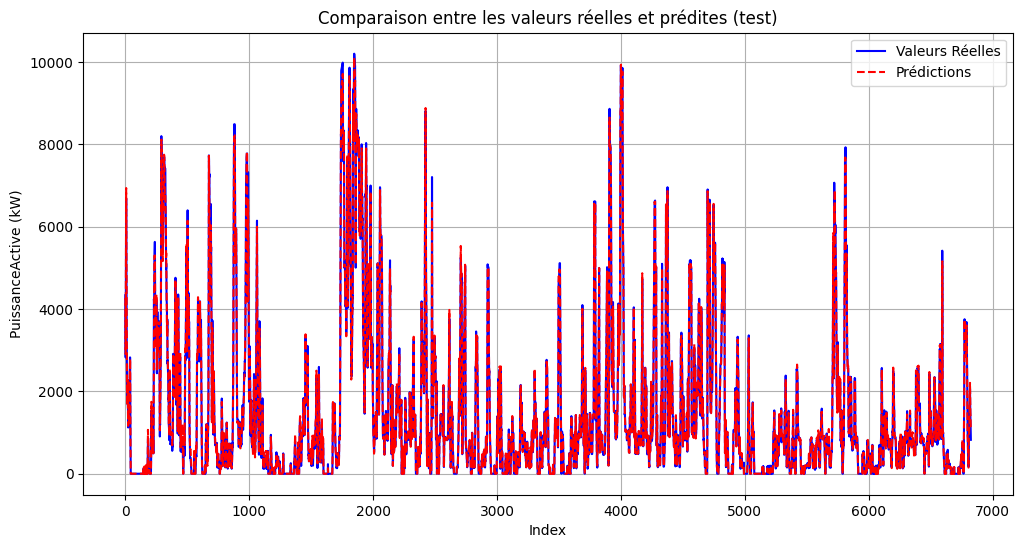

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Valeurs Réelles', color='blue')
plt.plot(y_pred_final, label='Prédictions', color='red', linestyle='--')
plt.title("Comparaison entre les valeurs réelles et prédites (test)")
plt.xlabel("Index")
plt.ylabel("PuissanceActive (kW)")
plt.legend()
plt.grid(True)
plt.show()

Évaluation par plage de production

Avec mask

In [3]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Fonction SMAPE
def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8))

# Fonction d'évaluation par plage
def eval_par_plage(y_true, y_pred, plage_name, mask):
    # Conversion en MW
    y_true_plage = y_true[mask] / 1000
    y_pred_plage = y_pred[mask] / 1000

    if len(y_true_plage) == 0:
        print(f"\nAucune donnée dans la plage '{plage_name}'.")
        return

    mse_p = mean_squared_error(y_true_plage, y_pred_plage)
    rmse_p = np.sqrt(mse_p)
    mae_p = mean_absolute_error(y_true_plage, y_pred_plage)
    r2_p = r2_score(y_true_plage, y_pred_plage)
    mape_p = np.mean(np.abs((y_true_plage - y_pred_plage) / y_true_plage.clip(lower=1e-8))) * 100
    nmae_p = mae_p / (np.max(y_true_plage) - np.min(y_true_plage) + 1e-8) * 100
    smape_p = smape(y_true_plage, y_pred_plage)

    range_y = np.max(y_true_plage) - np.min(y_true_plage)
    nrmse_range = (rmse_p / range_y) * 100 if range_y > 0 else float('inf')
    nmse_range = (mse_p / (range_y ** 2)) * 100 if range_y > 0 else float('inf')

    print(f"\n Évaluation pour la plage '{plage_name}' (en MW) :")
    print(f" - MSE     : {mse_p:.4f} MW²")
    print(f" - RMSE    : {rmse_p:.4f} MW")
    print(f" - MAE     : {mae_p:.4f} MW")
    print(f" - R2      : {r2_p:.4f}")
    print(f" - MAPE    : {mape_p:.4f}%")
    print(f" - SMAPE   : {smape_p:.4f}%")
    print(f" - NMSE    : {nmse_range:.4f}%")
    print(f" - NRMSE   : {nrmse_range:.4f}%")
    print(f" - NMAE    : {nmae_p:.4f}%")


mask_test = (X_test['VitesseVent (m/s)'] > 3) & (X_test['VitesseVent (m/s)'] <= 25)

# Filtrer les vraies valeurs et les prédictions
y_test_masked = y_test[mask_test]
y_pred_masked = y_pred_final[mask_test]

# Définir les masques de plage de production (sur les données filtrées)
mask_basse = y_test_masked < 1000
mask_moyenne = (y_test_masked >= 1000) & (y_test_masked < 8000)
mask_haute = y_test_masked >= 8000

# Évaluer par plage
eval_par_plage(y_test_masked, y_pred_masked, 'Basse production (<1000)', mask_basse)
eval_par_plage(y_test_masked, y_pred_masked, 'Moyenne production (1000-8000)', mask_moyenne)
eval_par_plage(y_test_masked, y_pred_masked, 'Haute production (>=8000)', mask_haute)


 Évaluation pour la plage 'Basse production (<1000)' (en MW) :
 - MSE     : 0.0047 MW²
 - RMSE    : 0.0687 MW
 - MAE     : 0.0445 MW
 - R2      : 0.9405
 - MAPE    : 10.8112%
 - SMAPE   : 9.9421%
 - NMSE    : 0.5305%
 - NRMSE   : 7.2834%
 - NMAE    : 4.7208%

 Évaluation pour la plage 'Moyenne production (1000-8000)' (en MW) :
 - MSE     : 0.0126 MW²
 - RMSE    : 0.1124 MW
 - MAE     : 0.0740 MW
 - R2      : 0.9959
 - MAPE    : 2.9178%
 - SMAPE   : 2.9189%
 - NMSE    : 0.0258%
 - NRMSE   : 1.6055%
 - NMAE    : 1.0567%

 Évaluation pour la plage 'Haute production (>=8000)' (en MW) :
 - MSE     : 0.0558 MW²
 - RMSE    : 0.2363 MW
 - MAE     : 0.1744 MW
 - R2      : 0.8976
 - MAPE    : 1.8880%
 - SMAPE   : 1.9144%
 - NMSE    : 1.1871%
 - NRMSE   : 10.8953%
 - NMAE    : 8.0440%


Sur lenssemble de test

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8))

def eval_par_plage(y_true, y_pred, plage_name, mask):
    # Conversion en MW
    y_true_plage = y_true[mask] / 1000
    y_pred_plage = y_pred[mask] / 1000

    if len(y_true_plage) == 0:
        print(f"\n Aucune donnée dans la plage '{plage_name}'.")
        return

    mse_p = mean_squared_error(y_true_plage, y_pred_plage)
    rmse_p = np.sqrt(mse_p)
    mae_p = mean_absolute_error(y_true_plage, y_pred_plage)
    r2_p = r2_score(y_true_plage, y_pred_plage)
    mape_p = np.mean(np.abs((y_true_plage - y_pred_plage) / y_true_plage.clip(lower=1e-8))) * 100
    nmae_p = mae_p / (np.max(y_true_plage) - np.min(y_true_plage) + 1e-8) * 100
    smape_p = smape(y_true_plage, y_pred_plage)

    range_y = np.max(y_true_plage) - np.min(y_true_plage)
    nrmse_range = (rmse_p / range_y) * 100 if range_y > 0 else float('inf')
    nmse_range = (mse_p / (range_y ** 2)) * 100 if range_y > 0 else float('inf')

    print(f"\n Évaluation pour la plage '{plage_name}' (en MW) :")
    print(f" - MSE                : {mse_p:.4f} MW²")
    print(f" - RMSE               : {rmse_p:.4f} MW")
    print(f" - MAE                : {mae_p:.4f} MW")
    print(f" - R2                 : {r2_p:.4f}")
    print(f" - MAPE               : {mape_p:.4f}%")
    print(f" - SMAPE              : {smape_p:.4f}%")
    print(f" - NMSE               : {nmse_range:.4f}%")
    print(f" - NRMSE              : {nrmse_range:.4f}%")
    print(f" - NMAE               : {nmae_p:.4f}%")

# Définir les masques pour les plages
mask_basse = y_test < 1000
mask_moyenne = (y_test >= 1000) & (y_test < 8000)
mask_haute = y_test >= 8000

eval_par_plage(y_test, y_pred_final, 'Basse production (<1000)', mask_basse)
eval_par_plage(y_test, y_pred_final, 'Moyenne production (1000-8000)', mask_moyenne)
eval_par_plage(y_test, y_pred_final, 'Haute production (>=8000)', mask_haute)


 Évaluation pour la plage 'Basse production (<1000)' (en MW) :
 - MSE                : 0.0034 MW²
 - RMSE               : 0.0586 MW
 - MAE                : 0.0324 MW
 - R2                 : 0.9716
 - MAPE               : 7.8795%
 - SMAPE              : 7.2720%
 - NMSE               : 0.3439%
 - NRMSE              : 5.8639%
 - NMAE               : 3.2411%

 Évaluation pour la plage 'Moyenne production (1000-8000)' (en MW) :
 - MSE                : 0.0126 MW²
 - RMSE               : 0.1124 MW
 - MAE                : 0.0740 MW
 - R2                 : 0.9959
 - MAPE               : 2.9178%
 - SMAPE              : 2.9189%
 - NMSE               : 0.0258%
 - NRMSE              : 1.6055%
 - NMAE               : 1.0567%

 Évaluation pour la plage 'Haute production (>=8000)' (en MW) :
 - MSE                : 0.0558 MW²
 - RMSE               : 0.2363 MW
 - MAE                : 0.1744 MW
 - R2                 : 0.8976
 - MAPE               : 1.8880%
 - SMAPE              : 1.9144%
 - NMSE        

Prédiction sur les dernières 24 heures

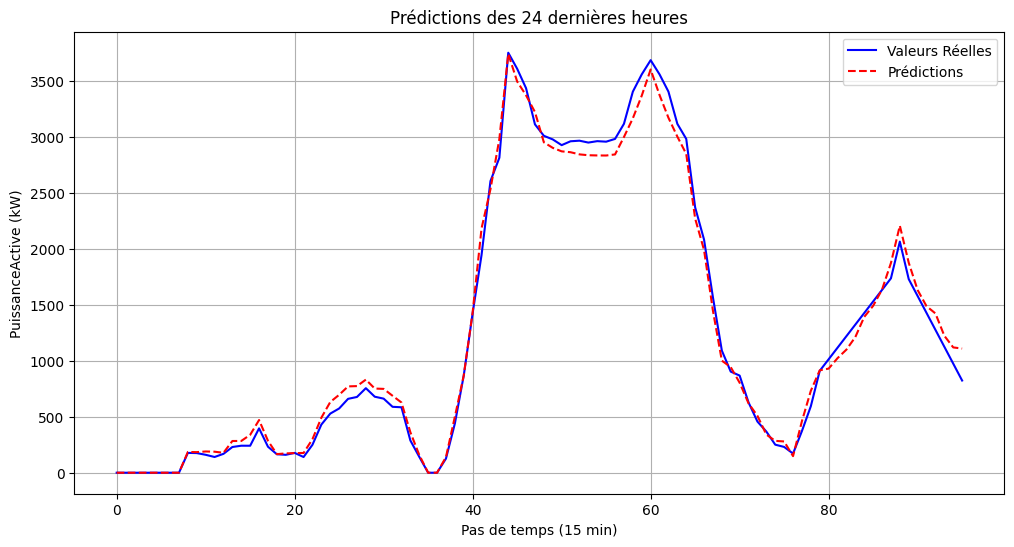

In [ ]:
# Sélection des 24 dernières heures
X_last_24h = test[feature_columns].tail(96).copy()
y_last_24h = test[target_column].tail(96).copy().reset_index(drop=True)

# Application du masque de vitesse de vent
mask_24h = (X_last_24h['VitesseVent (m/s)'] > 3) & (X_last_24h['VitesseVent (m/s)'] <= 25)
X_last_24h_masked = X_last_24h[mask_24h]

# Mise à l'échelle avec le scaler final
X_last_24h_scaled = pd.DataFrame(scaler_X_final.transform(X_last_24h_masked), columns=X_last_24h_masked.columns)

# Prédiction et déscaling
y_pred_24h_scaled = model_final.predict(X_last_24h_scaled)
y_pred_24h = scaler_y_final.inverse_transform(y_pred_24h_scaled.reshape(-1, 1)).flatten()

# Construction du vecteur final avec 0 si hors masque
y_pred_24h_final = np.zeros(len(X_last_24h))
y_pred_24h_final[mask_24h] = y_pred_24h
y_pred_24h_final[~mask_24h] = 0

plt.figure(figsize=(12, 6))
plt.plot(y_last_24h, label="Valeurs Réelles", color="blue")
plt.plot(y_pred_24h_final, label="Prédictions", color="red", linestyle="--")
plt.title("Prédictions des 24 dernières heures")
plt.xlabel("Pas de temps (15 min)")
plt.ylabel("PuissanceActive (kW)")
plt.legend()
plt.grid(True)
plt.show()

Sauvegarde du modèle et des prédictions

In [ ]:
import pickle
from google.colab import files

with open('/content/lightgbm_model.pkl', 'wb') as f:
    pickle.dump(model_final, f)

np.save("/content/predictions_lgb.npy", y_pred_final)

print("Modèle et prédictions sauvegardés !")

files.download("/content/predictions_lgb.npy")
files.download("/content/lightgbm_model.pkl")

Modèle et prédictions sauvegardés !


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>